# intervalNets test suite notebook

End-to-end sanity checks for interval forward propagation, norms, and Jacobians.


## Initialization

If you installed the project with `pip install -e .`, you can skip the next code cell path setup. If you are running directly from a repo checkout, the next cell adds the local `src/` directory to `sys.path` so `import intervalnets` works.


In [3]:
import sys
from pathlib import Path
import os
# Workaround for OpenMP duplicate-runtime kernel crashes in some Torch/Matplotlib envs.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import torch
from torch import nn

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src" / "intervalnets").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root containing src/intervalnets.")

repo_root = find_repo_root(Path.cwd().resolve())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from intervalnets import IntervalAdd, IntervalCat, IntervalTensor, enable_interval_eval

torch.set_printoptions(precision=17)
enable_interval_eval()
print(f"Using repo root: {repo_root}")

Using repo root: C:\Users\Phili\Documents\FastCoding\intervalNets\intervalNets


In [4]:
def report_pass(name: str) -> None:
    print(f"✅ PASS: {name}")


## 1. Random linear network

A random affine network shows the general propagation path.

In [6]:
torch.manual_seed(7)
random_model = nn.Sequential(
    nn.Linear(3, 4),
    nn.Linear(4, 2),
)
random_interval = IntervalTensor.from_bounds([0.0, -1.0, 2.0], [0.2, -0.8, 2.3])
random_output = random_model.eval(random_interval)
print(random_output)

assert len(random_output.lower) == 2
assert len(random_output.upper) == 2
assert all(lb < ub for lb, ub in zip(random_output.lower, random_output.upper))
report_pass("Random linear network interval eval executes and returns non-degenerate bounds")


IntervalTensor(lower=(-0.012124294012787832, 0.007999517397837065), upper=(0.20871881083948213, 0.14191499726128273))
✅ PASS: Random linear network interval eval executes and returns non-degenerate bounds


## 2. Zero network

Even a degenerate zero input produces a nonzero-width output interval because we expand point intervals outward to capture roundoff.

In [8]:
zero_model = nn.Linear(3, 2)
with torch.no_grad():
    zero_model.weight.zero_()
    zero_model.bias.zero_()

zero_interval = IntervalTensor.point([0.0, 0.0, 0.0])
zero_output = zero_model.eval(zero_interval)
print(zero_output)
assert all(lower < 0.0 for lower in zero_output.lower)
assert all(upper > 0.0 for upper in zero_output.upper)
report_pass("Zero network output encloses zero with outward rounding")


IntervalTensor(lower=(-4e-323, -4e-323), upper=(4e-323, 4e-323))
✅ PASS: Zero network output encloses zero with outward rounding


## 3. Hand-computable linear network

This example is easy to verify analytically because it is purely affine.

In [10]:
linear_model = nn.Linear(2, 1)
with torch.no_grad():
    linear_model.weight.copy_(torch.tensor([[2.0, -3.0]]))
    linear_model.bias.copy_(torch.tensor([0.5]))

linear_interval = IntervalTensor.from_bounds([1.0, 2.0], [1.5, 2.5])
linear_output = linear_model.eval(linear_interval)
print(linear_output)

candidates = [
    2.0 * x1 - 3.0 * x2 + 0.5
    for x1 in (1.0, 1.5)
    for x2 in (2.0, 2.5)
]
assert linear_output.lower[0] <= min(candidates)
assert linear_output.upper[0] >= max(candidates)
report_pass("Hand-computable linear network encloses exact corner evaluations")


IntervalTensor(lower=(-5.000000029802326,), upper=(-2.4999999403953526,))
✅ PASS: Hand-computable linear network encloses exact corner evaluations


## 4. Identity-style sanity check

The network should preserve the input interval up to outward rounding when it acts like the identity map.

In [12]:
identity_model = nn.Linear(2, 2)
with torch.no_grad():
    identity_model.weight.copy_(torch.eye(2))
    identity_model.bias.zero_()

identity_interval = IntervalTensor.from_bounds([-1.0, 4.0], [1.0, 5.0])
identity_output = identity_model.eval(identity_interval)
print(identity_output)
assert identity_output.lower[0] <= -1.0
assert identity_output.upper[0] >= 1.0
assert identity_output.lower[1] <= 4.0
assert identity_output.upper[1] >= 5.0
report_pass("Identity-style network preserves interval endpoints")


IntervalTensor(lower=(-1.0000000000000009, 3.9999999999999987), upper=(1.0000000000000009, 5.000000000000003))
✅ PASS: Identity-style network preserves interval endpoints


## 5. ReLU test cases

These examples mirror the dedicated ReLU tests in `tests/test_pytorch.py`. Each case uses assertions and then prints a clear `PASS` message when the expected interval behavior is verified.


In [14]:
# ReLU test 1: strictly negative intervals map to an outward-rounded zero interval.
relu = nn.ReLU()
negative_interval = IntervalTensor.from_bounds([-3.0, -0.5], [-1.0, -0.25])
negative_output = relu.eval(negative_interval)
assert all(lower < 0.0 for lower in negative_output.lower)
assert all(upper > 0.0 for upper in negative_output.upper)
report_pass("ReLU negative interval rounds outward to zero")

# ReLU test 2: positive intervals keep their endpoint images, up to outward rounding.
positive_interval = IntervalTensor.from_bounds([0.25, 1.5], [0.5, 3.0])
positive_output = relu.eval(positive_interval)
assert positive_output.lower[0] <= 0.25
assert positive_output.upper[0] >= 0.5
assert positive_output.lower[1] <= 1.5
assert positive_output.upper[1] >= 3.0
report_pass("ReLU positive interval preserves endpoint images")

# ReLU test 3: mixed-sign intervals are clamped only at the lower endpoint.
mixed_interval = IntervalTensor.from_bounds([-2.0, -1.0], [4.0, 2.5])
mixed_output = relu.eval(mixed_interval)
assert mixed_output.lower[0] < 0.0
assert mixed_output.upper[0] >= 4.0
assert mixed_output.lower[1] < 0.0
assert mixed_output.upper[1] >= 2.5
report_pass("ReLU mixed interval clamps only the lower endpoint")

# ReLU test 4: a Linear -> ReLU -> Linear network encloses all endpoint evaluations.
relu_network = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1))
with torch.no_grad():
    relu_network[0].weight.copy_(torch.tensor([[1.0, -2.0], [-1.0, 0.5]]))
    relu_network[0].bias.copy_(torch.tensor([0.25, -0.75]))
    relu_network[2].weight.copy_(torch.tensor([[1.5, -0.5]]))
    relu_network[2].bias.copy_(torch.tensor([0.1]))

network_interval = IntervalTensor.from_bounds([-1.0, 0.5], [2.0, 1.5])
network_output = relu_network.eval(network_interval)
candidates = []
for x1 in (-1.0, 2.0):
    for x2 in (0.5, 1.5):
        hidden_1 = max(0.0, x1 - 2.0 * x2 + 0.25)
        hidden_2 = max(0.0, -x1 + 0.5 * x2 - 0.75)
        candidates.append(1.5 * hidden_1 - 0.5 * hidden_2 + 0.1)

assert network_output.lower[0] <= min(candidates)
assert network_output.upper[0] >= max(candidates)
report_pass("Linear -> ReLU -> Linear network encloses endpoint evaluations")

print("All ReLU notebook tests passed.")


✅ PASS: ReLU negative interval rounds outward to zero
✅ PASS: ReLU positive interval preserves endpoint images
✅ PASS: ReLU mixed interval clamps only the lower endpoint
✅ PASS: Linear -> ReLU -> Linear network encloses endpoint evaluations
All ReLU notebook tests passed.


Upper and lower bounds should be different and not constant!


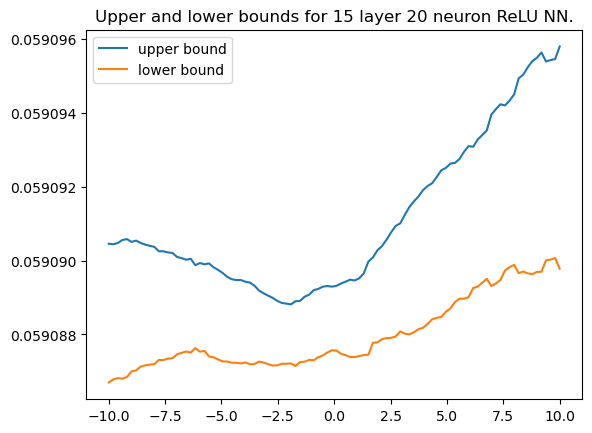

In [15]:
import matplotlib.pyplot as plt
torch.manual_seed(1)

random_model = nn.Sequential(
    nn.Linear(1, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 1),
)

x_all = np.linspace(-10,10, 100)
out_low = []
out_up = []

for k in range(len(x_all)):
    random_interval = IntervalTensor.from_bounds([x_all[k]], [x_all[k]])
    random_output = random_model.eval(random_interval)
    out_low.append(random_output.lower[0])
    out_up.append(random_output.upper[0])

plt.plot(x_all, np.array(out_up), label = "upper bound")
plt.plot(x_all, np.array(out_low), label = "lower bound")
plt.title("Upper and lower bounds for 15 layer 20 neuron ReLU NN.")
plt.legend()
print("Upper and lower bounds should be different and not constant!")

## 6. Sigmoid test cases

These examples validate interval propagation through `nn.Sigmoid()`, which is monotone increasing and therefore should map interval endpoints directly (with outward rounding).


In [17]:
sigmoid = nn.Sigmoid()

# Sigmoid test 1: endpoint images are enclosed for a generic interval.
sigmoid_interval = IntervalTensor.from_bounds([-2.0, 0.0], [1.0, 3.0])
sigmoid_output = sigmoid.eval(sigmoid_interval)
expected_lower = torch.sigmoid(torch.tensor([-2.0, 0.0], dtype=torch.float64)).tolist()
expected_upper = torch.sigmoid(torch.tensor([1.0, 3.0], dtype=torch.float64)).tolist()
for idx in range(2):
    assert sigmoid_output.lower[idx] <= expected_lower[idx]
    assert sigmoid_output.upper[idx] >= expected_upper[idx]
report_pass("Sigmoid encloses endpoint images")

# Sigmoid test 2: output bounds are valid probabilities and ordered.
wide_interval = IntervalTensor.from_bounds([-8.0, -1.0, 0.5], [0.0, 2.0, 6.0])
wide_output = sigmoid.eval(wide_interval)
assert all(0.0 <= lower <= 1.0 for lower in wide_output.lower)
assert all(0.0 <= upper <= 1.0 for upper in wide_output.upper)
assert all(lower <= upper for lower, upper in zip(wide_output.lower, wide_output.upper))
report_pass("Sigmoid outputs stay within [0, 1] and preserve order")

# Sigmoid test 3: point intervals are expanded outward around exact sigmoid values.
point_input = [0.0, -0.75, 1.25]
point_interval = IntervalTensor.point(point_input)
point_output = sigmoid.eval(point_interval)
point_exact = torch.sigmoid(torch.tensor(point_input, dtype=torch.float64)).tolist()
for idx, exact in enumerate(point_exact):
    assert point_output.lower[idx] < exact < point_output.upper[idx]
report_pass("Sigmoid point interval is outward non-degenerate")

# Sigmoid test 4: a Linear -> Sigmoid -> Linear network encloses corner evaluations.
sigmoid_network = nn.Sequential(nn.Linear(2, 2), nn.Sigmoid(), nn.Linear(2, 1))
with torch.no_grad():
    sigmoid_network[0].weight.copy_(torch.tensor([[1.2, -0.7], [-0.5, 0.9]]))
    sigmoid_network[0].bias.copy_(torch.tensor([0.1, -0.2]))
    sigmoid_network[2].weight.copy_(torch.tensor([[0.8, -1.1]]))
    sigmoid_network[2].bias.copy_(torch.tensor([0.05]))

sigmoid_network_interval = IntervalTensor.from_bounds([-1.0, -0.5], [1.5, 2.0])
sigmoid_network_output = sigmoid_network.eval(sigmoid_network_interval)
sigmoid_candidates = []
for x1 in (sigmoid_network_interval.lower[0], sigmoid_network_interval.upper[0]):
    for x2 in (sigmoid_network_interval.lower[1], sigmoid_network_interval.upper[1]):
        hidden_1 = torch.sigmoid(torch.tensor(1.2 * x1 - 0.7 * x2 + 0.1, dtype=torch.float64)).item()
        hidden_2 = torch.sigmoid(torch.tensor(-0.5 * x1 + 0.9 * x2 - 0.2, dtype=torch.float64)).item()
        sigmoid_candidates.append(0.8 * hidden_1 - 1.1 * hidden_2 + 0.05)

assert sigmoid_network_output.lower[0] <= min(sigmoid_candidates)
assert sigmoid_network_output.upper[0] >= max(sigmoid_candidates)
report_pass("Linear -> Sigmoid -> Linear network encloses corner evaluations")

print("All Sigmoid notebook tests passed.")

print("\nSanity check: unsupported activations still raise NotImplementedError.")
unsupported_model = nn.Sequential(nn.Linear(2, 2), nn.Tanh())
try:
    unsupported_model.eval(IntervalTensor.point([0.0, 1.0]))
except NotImplementedError as exc:
    print(type(exc).__name__, exc)


✅ PASS: Sigmoid encloses endpoint images
✅ PASS: Sigmoid outputs stay within [0, 1] and preserve order
✅ PASS: Sigmoid point interval is outward non-degenerate
✅ PASS: Linear -> Sigmoid -> Linear network encloses corner evaluations
All Sigmoid notebook tests passed.

Sanity check: unsupported activations still raise NotImplementedError.


Upper and lower bounds should be different and not constant!


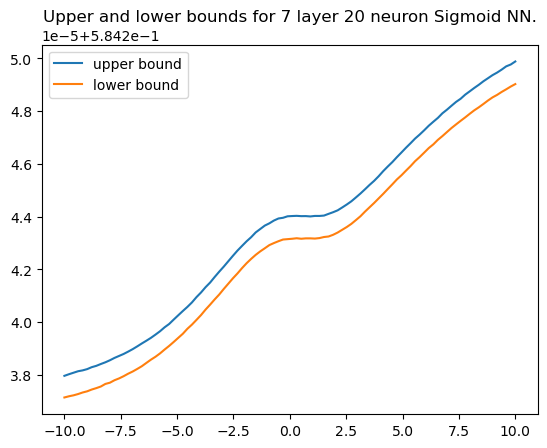

In [18]:
torch.manual_seed(2)

random_model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),  
    nn.Linear(20, 1),
)

x_all = np.linspace(-10,10, 100)
out_low = []
out_up = []

for k in range(len(x_all)):
    random_interval = IntervalTensor.from_bounds([x_all[k]], [x_all[k]])
    random_output = random_model.eval(random_interval)
    out_low.append(random_output.lower[0])
    out_up.append(random_output.upper[0])

plt.plot(x_all, np.array(out_up), label = "upper bound")
plt.plot(x_all, np.array(out_low), label = "lower bound")
plt.title("Upper and lower bounds for 7 layer 20 neuron Sigmoid NN.")
plt.legend()
print("Upper and lower bounds should be different and not constant!")

## 7. Lp norm adaptive refinement tests


✅ PASS: Lp norm: zero network integrates to zero
✅ PASS: Lp norm: refinement tightens bounds
✅ PASS: Lp norm: Monte Carlo estimate enclosed
coarse bounds: Interval(lower=1.673286564322445, upper=1.8420133097318263)
refined bounds: Interval(lower=1.6946683300792582, upper=1.820294819620602)
Monte Carlo estimate: 0.3127980154329596
Interval bounds: Interval(lower=0.2546021527629654, upper=0.37248465838592437)


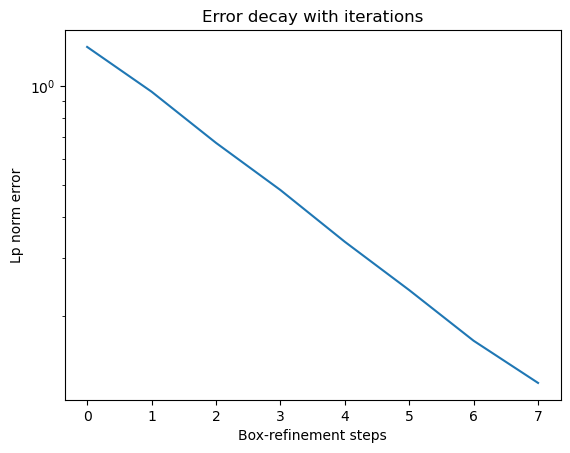

In [20]:
# Lp test 1: zero network should have zero L2 norm on any box.
zero_norm_model = nn.Sequential(nn.Linear(2, 1))
with torch.no_grad():
    zero_norm_model[0].weight.zero_()
    zero_norm_model[0].bias.zero_()

norm_domain = IntervalTensor.from_bounds([-1.0, -2.0], [3.0, 4.0])
zero_norm_bounds = zero_norm_model.lpnorm(norm_domain, p=2.0, iterations=8)
assert zero_norm_bounds.lower <= 0.0 <= zero_norm_bounds.upper
assert zero_norm_bounds.upper < 1e-10
report_pass("Lp norm: zero network integrates to zero")

# Lp test 2: adaptive refinement should tighten enclosures.
torch.manual_seed(11)
refinement_model = nn.Sequential(nn.Linear(1, 12), nn.ReLU(), nn.Linear(12, 1))
for parameter in refinement_model.parameters():
    nn.init.uniform_(parameter, a=-1.0, b=1.0)

refinement_domain = IntervalTensor.from_bounds([-1.0], [1.0])

iterations = 8
errors = np.zeros([iterations])

for o in range(iterations):
    coarse_bounds = refinement_model.lpnorm(refinement_domain, p=2.0, iterations=o)
    refined_bounds = refinement_model.lpnorm(refinement_domain, p=2.0, iterations=o+1)
    errors[o] = refined_bounds.upper - refined_bounds.lower
    assert refined_bounds.lower >= coarse_bounds.lower
    assert refined_bounds.upper <= coarse_bounds.upper

report_pass("Lp norm: refinement tightens bounds")
plt.semilogy(errors)
plt.xlabel("Box-refinement steps")
plt.ylabel("Lp norm error")
plt.title("Error decay with iterations")

# Lp test 3: Monte Carlo estimate should lie inside interval enclosure.
torch.manual_seed(7)
mc_model = nn.Sequential(nn.Linear(2, 6), nn.ReLU(), nn.Linear(6, 1))
mc_domain = IntervalTensor.from_bounds([-1.0, -0.5], [1.0, 1.5])
mc_bounds = mc_model.lpnorm(mc_domain, p=2.0, iterations=10)

num_samples = 30000
with torch.no_grad():
    samples = torch.rand(num_samples, 2, dtype=torch.float64)
    samples[:, 0] = 2.0 * samples[:, 0] - 1.0
    samples[:, 1] = 2.0 * samples[:, 1] - 0.5
    values = mc_model(samples.to(dtype=torch.float32)).to(dtype=torch.float64).squeeze(-1)
    integrand = torch.abs(values) ** 2.0
    volume = (1.0 - (-1.0)) * (1.5 - (-0.5))
    mc_estimate = float((volume * torch.mean(integrand)).sqrt().item())

assert mc_bounds.lower <= mc_estimate <= mc_bounds.upper
report_pass("Lp norm: Monte Carlo estimate enclosed")

print("coarse bounds:", coarse_bounds)
print("refined bounds:", refined_bounds)
print("Monte Carlo estimate:", mc_estimate)
print("Interval bounds:", mc_bounds)



## 8. Jacobian and Sobolev norm tests


✅ PASS: Jacobian: linear layer encloses exact matrix
✅ PASS: Jacobian: ReLU crossing-zero derivative interval
✅ PASS: Sobolev norm: constant network closed form
✅ PASS: Sobolev norm: refinement tightens bounds
Linear Jacobian bounds: IntervalTensor(lower=((1.9999999999999998, -1.0000000000000002), (0.49999997019767756, 2.9999999999999996)), upper=((2.0000000000000004, -0.9999999999999999), (0.5000000596046449, 3.0000000000000004)))
Sobolev constant bounds: Interval(lower=4.242640687119282, upper=4.242640687119288)
Sobolev coarse bounds: Interval(lower=0.17453824565201598, upper=0.2868257507028709)
Sobolev refined bounds: Interval(lower=0.1873054299872695, upper=0.2697645037723128)


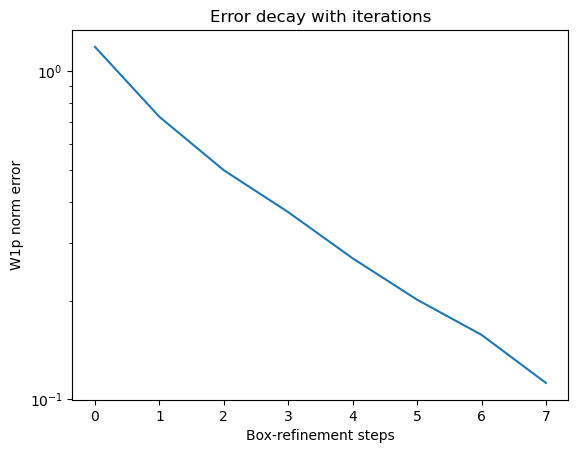

In [22]:
# Jacobian test 1: linear layer Jacobian encloses exact weight matrix.
jac_layer = nn.Linear(2, 2)
with torch.no_grad():
    jac_layer.weight.copy_(torch.tensor([[2.0, -1.0], [0.5, 3.0]]))
    jac_layer.bias.copy_(torch.tensor([1.0, -2.0]))

jac_domain = IntervalTensor.from_bounds([-1.0, -2.0], [2.0, 4.0])
jac_bounds = jac_layer.eval_jacobian(jac_domain)
expected_jac = [[2.0, -1.0], [0.5, 3.0]]
for i, row in enumerate(expected_jac):
    for j, exact in enumerate(row):
        assert jac_bounds.lower[i][j] <= exact <= jac_bounds.upper[i][j]
report_pass("Jacobian: linear layer encloses exact matrix")

# Jacobian test 2: ReLU crossing zero has derivative interval [0, 1].
relu = nn.ReLU()
relu_domain = IntervalTensor.from_bounds([-2.0, 0.25], [1.0, 2.5])
relu_jac = relu.eval_jacobian(relu_domain)
assert relu_jac.lower[0][0] <= 0.0
assert relu_jac.upper[0][0] >= 1.0
assert relu_jac.lower[1][1] <= 1.0 <= relu_jac.upper[1][1]
report_pass("Jacobian: ReLU crossing-zero derivative interval")

# Sobolev test 1: constant network has closed-form W^{1,2} norm equal to L2 norm.
sobolev_const_model = nn.Sequential(nn.Linear(1, 1))
with torch.no_grad():
    sobolev_const_model[0].weight.zero_()
    sobolev_const_model[0].bias.fill_(3.0)

sobolev_domain = IntervalTensor.from_bounds([0.0], [2.0])
sobolev_bounds = sobolev_const_model.sobolev_norm(sobolev_domain, p=2.0, iterations=4)
exact_sobolev = (18.0) ** 0.5
assert sobolev_bounds.lower <= exact_sobolev <= sobolev_bounds.upper
assert (sobolev_bounds.upper - sobolev_bounds.lower) < 1e-6
report_pass("Sobolev norm: constant network closed form")

# Sobolev test 2: adaptive refinement should tighten enclosures.
torch.manual_seed(13)
sobolev_refinement_model = nn.Sequential(nn.Linear(1, 6), nn.ReLU(), nn.Linear(6, 1))
for parameter in sobolev_refinement_model.parameters():
    nn.init.uniform_(parameter, a=-1.0, b=1.0)

sobolev_refine_domain = IntervalTensor.from_bounds([-1.0], [1.0])
iterations = 8
errors = np.zeros([iterations])

for o in range(iterations):
    sobolev_coarse = sobolev_refinement_model.sobolev_norm(sobolev_refine_domain, p=2.0, iterations=o)
    sobolev_refined = sobolev_refinement_model.sobolev_norm(sobolev_refine_domain, p=2.0, iterations=o+1)
    errors[o] = sobolev_coarse.upper - sobolev_coarse.lower
    assert refined_bounds.lower >= coarse_bounds.lower
    assert refined_bounds.upper <= coarse_bounds.upper
report_pass("Sobolev norm: refinement tightens bounds")

plt.semilogy(errors)
plt.xlabel("Box-refinement steps")
plt.ylabel("W1p norm error")
plt.title("Error decay with iterations")


print("Linear Jacobian bounds:", jac_bounds)
print("Sobolev constant bounds:", sobolev_bounds)
print("Sobolev coarse bounds:", sobolev_coarse)
print("Sobolev refined bounds:", sobolev_refined)



## 9. Additional validation and error-path tests

These notebook checks mirror the stricter pytest coverage: invalid inputs, API semantics, and unsupported modes.


In [24]:
# Additional test-suite style checks in notebook form.
import math

# 1) Interval validation
try:
    IntervalTensor.from_bounds([1.0, 2.0], [1.0])
    raise AssertionError("Expected ValueError for mismatched shapes")
except ValueError:
    report_pass("shape mismatch rejected")

try:
    IntervalTensor.from_bounds(2.0, 1.0)
    raise AssertionError("Expected ValueError for lower > upper")
except ValueError:
    report_pass("invalid scalar bounds rejected")

# 2) Softmax dimension / empty checks
softmax = nn.Softmax(dim=-1)
try:
    softmax.eval(IntervalTensor.from_bounds([], []))
    raise AssertionError("Expected ValueError for empty softmax input")
except ValueError:
    report_pass("empty softmax interval rejected")

softmax = nn.Softmax(dim=1)
    
try:
    softmax.eval(IntervalTensor.from_bounds([-1.0, 0.0], [1.0, 2.0]))
    raise AssertionError("Expected NotImplementedError for unsupported dim")
except NotImplementedError:
    report_pass("unsupported softmax dim rejected")

# 3) API lifecycle checks
enable_interval_eval()
enable_interval_eval()  # idempotent
model = nn.Sequential(nn.Linear(2, 1))
assert model.eval() is model
report_pass("enable_interval_eval is idempotent and preserves model.eval()")

try:
    model.eval([0.0, 1.0])
    raise AssertionError("Expected TypeError for non-interval eval argument")
except TypeError:
    report_pass("model.eval(interval) enforces IntervalTensor input")

# 4) Sigmoid forward enclosure
sigmoid = nn.Sigmoid()
sig_interval = IntervalTensor.from_bounds([-3.0, -0.25, 2.0], [-1.0, 0.5, 4.0])
sig_bounds = sigmoid.eval(sig_interval)
exact_lower = torch.sigmoid(torch.tensor(sig_interval.lower, dtype=torch.float64)).tolist()
exact_upper = torch.sigmoid(torch.tensor(sig_interval.upper, dtype=torch.float64)).tolist()
for i in range(len(exact_lower)):
    assert sig_bounds.lower[i] <= exact_lower[i]
    assert sig_bounds.upper[i] >= exact_upper[i]
report_pass("sigmoid endpoint enclosure")

✅ PASS: shape mismatch rejected
✅ PASS: invalid scalar bounds rejected
✅ PASS: empty softmax interval rejected
✅ PASS: unsupported softmax dim rejected
✅ PASS: enable_interval_eval is idempotent and preserves model.eval()
✅ PASS: model.eval(interval) enforces IntervalTensor input
✅ PASS: sigmoid endpoint enclosure


## 10.New activation + branch-combinator checks

In [26]:
# 10.1 Tanh endpoint enclosure
tanh = nn.Tanh()
tanh_interval = IntervalTensor.from_bounds([-1.5, -0.1], [0.5, 2.0])
tanh_bounds = tanh.eval(tanh_interval)
for idx in range(len(tanh_interval.lower)):
    lo = math.tanh(tanh_interval.lower[idx])
    hi = math.tanh(tanh_interval.upper[idx])
    assert tanh_bounds.lower[idx] <= lo
    assert tanh_bounds.upper[idx] >= hi
report_pass("Tanh encloses endpoint images")

# 10.2 Softplus endpoint enclosure
softplus = nn.Softplus(beta=1.0, threshold=20.0)
sp_interval = IntervalTensor.from_bounds([-2.0, 0.25], [1.0, 3.0])
sp_bounds = softplus.eval(sp_interval)
for idx in range(len(sp_interval.lower)):
    lo = math.log1p(math.exp(sp_interval.lower[idx]))
    hi = math.log1p(math.exp(sp_interval.upper[idx]))
    assert sp_bounds.lower[idx] <= lo
    assert sp_bounds.upper[idx] >= hi
report_pass("Softplus encloses endpoint images")

# 10.3 LeakyReLU endpoint enclosure
leaky = nn.LeakyReLU(negative_slope=0.2)
leaky_interval = IntervalTensor.from_bounds([-3.0, -0.5, 0.2], [-1.0, 0.5, 1.5])
leaky_bounds = leaky.eval(leaky_interval)
for idx in range(len(leaky_interval.lower)):
    lo = leaky_interval.lower[idx] if leaky_interval.lower[idx] >= 0.0 else 0.2 * leaky_interval.lower[idx]
    hi = leaky_interval.upper[idx] if leaky_interval.upper[idx] >= 0.0 else 0.2 * leaky_interval.upper[idx]
    assert leaky_bounds.lower[idx] <= lo
    assert leaky_bounds.upper[idx] >= hi
report_pass("LeakyReLU encloses endpoint images")

# 10.4 IntervalAdd corner enclosure
add_model = IntervalAdd(
    nn.Sequential(nn.Linear(2, 2), nn.Tanh()),
    nn.Sequential(nn.Linear(2, 2), nn.LeakyReLU(negative_slope=0.1)),
)
with torch.no_grad():
    add_model.left[0].weight.copy_(torch.tensor([[1.0, -0.5], [0.5, 1.0]]))
    add_model.left[0].bias.copy_(torch.tensor([0.2, -0.1]))
    add_model.right[0].weight.copy_(torch.tensor([[0.25, 1.5], [-1.0, 0.5]]))
    add_model.right[0].bias.copy_(torch.tensor([0.0, 0.3]))

add_interval = IntervalTensor.from_bounds([-1.0, 0.25], [0.5, 1.0])
add_bounds = add_model.eval(add_interval)
add_eval_dtype = add_model.left[0].weight.dtype
for x0 in (add_interval.lower[0], add_interval.upper[0]):
    for x1 in (add_interval.lower[1], add_interval.upper[1]):
        corner_eval = add_model(torch.tensor([x0, x1], dtype=add_eval_dtype)).detach().tolist()
        for idx, exact in enumerate(corner_eval):
            assert add_bounds.lower[idx] <= exact <= add_bounds.upper[idx]
report_pass("IntervalAdd encloses branch-sum corner evaluations")

# 10.5 IntervalCat corner enclosure + dim validation
cat_model = IntervalCat(
    nn.Sequential(nn.Linear(2, 1), nn.Softplus()),
    nn.Sequential(nn.Linear(2, 2), nn.Tanh()),
    dim=-1,
)
with torch.no_grad():
    cat_model.branches[0][0].weight.copy_(torch.tensor([[1.0, -1.0]]))
    cat_model.branches[0][0].bias.copy_(torch.tensor([0.1]))
    cat_model.branches[1][0].weight.copy_(torch.tensor([[0.5, 0.25], [-0.75, 1.25]]))
    cat_model.branches[1][0].bias.copy_(torch.tensor([0.0, -0.2]))

cat_interval = IntervalTensor.from_bounds([-0.5, -1.0], [1.0, 0.75])
cat_bounds = cat_model.eval(cat_interval)
assert len(cat_bounds.lower) == 3 and len(cat_bounds.upper) == 3
cat_eval_dtype = cat_model.branches[0][0].weight.dtype
for x0 in (cat_interval.lower[0], cat_interval.upper[0]):
    for x1 in (cat_interval.lower[1], cat_interval.upper[1]):
        corner_eval = cat_model(torch.tensor([x0, x1], dtype=cat_eval_dtype)).detach().tolist()
        for idx, exact in enumerate(corner_eval):
            assert cat_bounds.lower[idx] <= exact <= cat_bounds.upper[idx]
report_pass("IntervalCat encloses branch-concat corner evaluations")

try:
    bad_cat = IntervalCat(nn.Identity(), nn.Identity(), dim=1)
    _ = bad_cat.eval(IntervalTensor.from_bounds([0.0, 1.0], [0.5, 1.5]))
    raise AssertionError("Expected NotImplementedError for unsupported IntervalCat dim")
except NotImplementedError:
    report_pass("IntervalCat rejects unsupported dimensions")


✅ PASS: Tanh encloses endpoint images
✅ PASS: Softplus encloses endpoint images
✅ PASS: LeakyReLU encloses endpoint images
✅ PASS: IntervalAdd encloses branch-sum corner evaluations
✅ PASS: IntervalCat encloses branch-concat corner evaluations
✅ PASS: IntervalCat rejects unsupported dimensions


## 11. Minimal interval multiplication comparison

This example uses **one small interval pair** and computes multiplication two ways so the difference is obvious and testable.

In [29]:
from math import inf, nextafter
from intervalnets import Interval

# Concrete test intervals
a_lo, a_hi = -1.0, 2.0
b_lo, b_hi = -3.0, 4.0

# Step-by-step standard products
ac = a_lo * b_lo
ad = a_lo * b_hi
bc = a_hi * b_lo
bd = a_hi * b_hi
products = (ac, ad, bc, bd)

std_lower = nextafter(min(products), -inf)
std_upper = nextafter(max(products), inf)

print('Products (ac, ad, bc, bd):', products)
print('Standard interval result:', (std_lower, std_upper))

A_tuple = Interval.from_bounds([a_lo], [a_hi])
B_tuple = Interval.from_bounds([b_lo], [b_hi])
lib_tuple_product = A_tuple * B_tuple

assert std_lower >= lib_tuple_product.lower[0]
assert std_upper <= lib_tuple_product.upper[0]
report_pass("Interval Multiplication works correctly")

Products (ac, ad, bc, bd): (3.0, -4.0, -6.0, 8.0)
Standard interval result: (-6.000000000000001, 8.000000000000002)



Difference vs standard:
  standard : (-6.000000000000001, 8.000000000000002)
✅ PASS: Interval Multiplication works correctly
